# Generating Large Dummy Dataset to perform BIG Data Analytics

In [1]:
!pip install faker
import pandas as pd
import random
from faker import Faker

fake = Faker()

categories = ['Electronics', 'Fashion', 'Grocery', 'Books', 'Sports', 'Home Decor']
payment_methods = ['UPI', 'Card', 'COD', 'NetBanking']
cities = ['Delhi', 'Mumbai', 'Lucknow', 'Bangalore', 'Hyderabad', 'Pune', 'Chennai']

rows = []

for i in range(100000):
    rows.append({
        'transaction_id': f'TXN{i+1000}',
        'customer_id': f'CUST{random.randint(100,999)}',
        'product_id': f'PRD{random.randint(100,999)}',
        'category': random.choice(categories),
        'product_price': random.randint(100,100000),
        'quantity': random.randint(1,5),
        'payment_method': random.choice(payment_methods),
        'city': random.choice(cities),
        'order_date': fake.date_between(start_date='-1y', end_date='today'),
        'delivery_days': random.randint(1,10),
        'rating': random.randint(1,5),
        'returned': random.choice(['Yes', 'No'])
    })

# Create DataFrame
_df = pd.DataFrame(rows)

# Save CSV
_df.to_csv('bigdata_dummy_dataset.csv', index=False)

print('Dataset Generated Successfully')

Dataset Generated Successfully


## 1.Data Processing

In [2]:
##Load Dataset
df = pd.read_csv("bigdata_dummy_dataset.csv")

print(df.head())
print(df.shape)
print(df.info())

  transaction_id customer_id product_id    category  product_price  quantity  \
0        TXN1000     CUST403     PRD816  Home Decor          11082         5   
1        TXN1001     CUST345     PRD230      Sports          45189         3   
2        TXN1002     CUST887     PRD864     Fashion          51511         5   
3        TXN1003     CUST424     PRD562     Fashion          10456         1   
4        TXN1004     CUST850     PRD937      Sports          41521         1   

  payment_method     city  order_date  delivery_days  rating returned  
0            COD    Delhi  2025-06-23             10       5       No  
1            UPI  Lucknow  2026-03-27              5       2      Yes  
2            COD    Delhi  2026-04-04              4       1      Yes  
3            UPI    Delhi  2025-11-22              8       3      Yes  
4            COD    Delhi  2025-09-08              9       5      Yes  
(100000, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 999

In [3]:
##Basic Cleaning

# Remove duplicates
df = df.drop_duplicates()

# Check null values
print(df.isnull().sum())

# Fill missing values if any
df = df.fillna(0)

transaction_id    0
customer_id       0
product_id        0
category          0
product_price     0
quantity          0
payment_method    0
city              0
order_date        0
delivery_days     0
rating            0
returned          0
dtype: int64


In [4]:
#Create New Column
df['total_amount'] = df['product_price'] * df['quantity']

print(df[['product_price', 'quantity', 'total_amount']].head())

   product_price  quantity  total_amount
0          11082         5         55410
1          45189         3        135567
2          51511         5        257555
3          10456         1         10456
4          41521         1         41521


## 2.Data Analysis

### Total Revenue

In [5]:
total_revenue = df['total_amount'].sum()

print("Total Revenue:", total_revenue)

Total Revenue: 15021908289


### Category-wise Revenue

In [6]:
category_sales = df.groupby('category')['total_amount'].sum()

print(category_sales)

category
Books          2519191526
Electronics    2521225837
Fashion        2515842900
Grocery        2470399946
Home Decor     2492424062
Sports         2502824018
Name: total_amount, dtype: int64


### Top Cities by Revenue

In [7]:
city_sales = df.groupby('city')['total_amount'].sum().sort_values(ascending=False)

print(city_sales)

city
Hyderabad    2161967997
Delhi        2156157430
Bangalore    2156061908
Pune         2154565714
Chennai      2149798972
Lucknow      2129747419
Mumbai       2113608849
Name: total_amount, dtype: int64


### Average Ratings

In [8]:
ratings = df.groupby('category')['rating'].mean()

print(ratings)

category
Books          3.018349
Electronics    2.979067
Fashion        3.001250
Grocery        2.971420
Home Decor     3.001084
Sports         3.010009
Name: rating, dtype: float64


### Returned Products Analysis

In [9]:
returns = df['returned'].value_counts()

print(returns)

returned
No     50030
Yes    49970
Name: count, dtype: int64


## 3.Numerical Analysis

### Convering Column to NumPy Array

In [10]:
import numpy as np

prices = np.array(df['product_price'])

print(prices[:10])

[11082 45189 51511 10456 41521 95741 90763 64122 72595 63374]


### Statistical Calculations

In [11]:
print("Mean Price:", np.mean(prices))
print("Max Price:", np.max(prices))
print("Min Price:", np.min(prices))
print("Standard Deviation:", np.std(prices))

Mean Price: 50109.84224
Max Price: 100000
Min Price: 100
Standard Deviation: 28914.931480500374


### Normalize Data

In [12]:
normalized_prices = (prices - np.min(prices)) / (np.max(prices) - np.min(prices))

print(normalized_prices[:5])

[0.10992993 0.45134134 0.51462462 0.10366366 0.41462462]


## 4.Data Visualisation

### Category Revenue Bar Chart

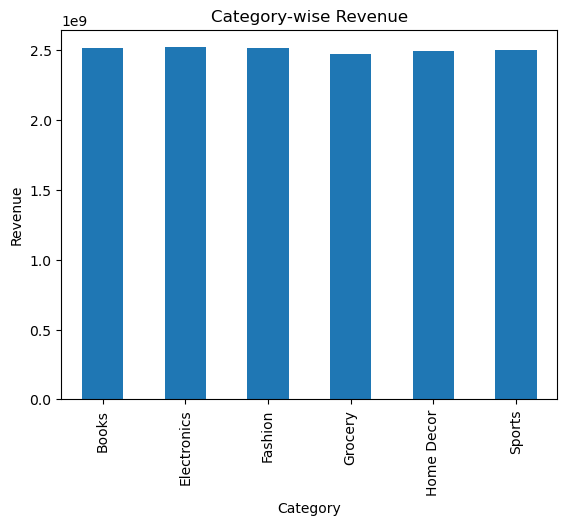

In [13]:
import matplotlib.pyplot as plt

category_sales.plot(kind='bar')

plt.title("Category-wise Revenue")
plt.xlabel("Category")
plt.ylabel("Revenue")

plt.show()

### Pie Chart for Payment Methods

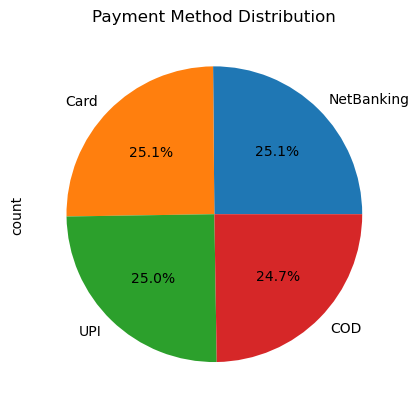

In [14]:
payment_counts = df['payment_method'].value_counts()

payment_counts.plot(kind='pie', autopct='%1.1f%%')

plt.title("Payment Method Distribution")

plt.show()

### Monthly Sales Trend

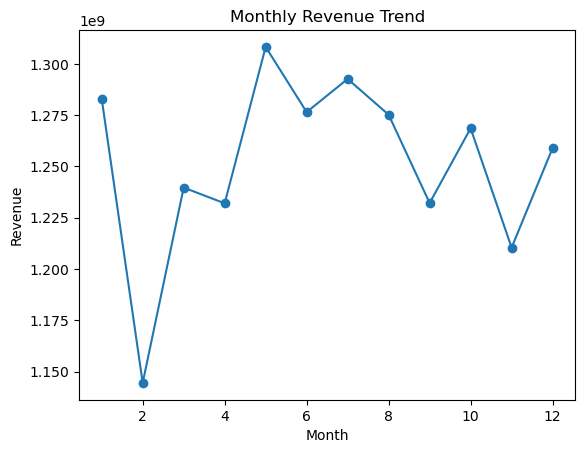

In [15]:
df['order_date'] = pd.to_datetime(df['order_date'])

df['month'] = df['order_date'].dt.month

monthly_sales = df.groupby('month')['total_amount'].sum()

monthly_sales.plot(kind='line', marker='o')

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.show()

# Distributed Analytics ( Using Pyspark)